In [1]:
from pathlib import Path
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

DATA_DIR = BASE_DIR / "databases"
OUTPUT_DIR = BASE_DIR / "outputs"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ["qwen", "llama3", "phi3_5_mini"]
DATASET_ORDER = ["folio", "prontoqa", "proofwriter"]

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

BASE_DIR: C:\Users\mathlouthi\POSS-LOGIC-LM
DATA_DIR: C:\Users\mathlouthi\POSS-LOGIC-LM\databases
OUTPUT_DIR: C:\Users\mathlouthi\POSS-LOGIC-LM\outputs


In [2]:
def detect_dataset_from_filename(path: Path) -> str:
    name = path.name.lower()

    if "folio" in name:
        return "folio"

    if "prontoqa" in name or "pronto" in name:
        return "prontoqa"

    if "proofwriter" in name or "proof" in name:
        return "proofwriter"

    raise ValueError(f"Impossible de détecter le dataset depuis le fichier : {path.name}")


def discover_databases(data_dir: Path) -> list[tuple[str, str, Path]]:
    database_files = []

    for model_dir in data_dir.iterdir():
        if not model_dir.is_dir():
            continue

        model = model_dir.name

        for json_path in model_dir.glob("*.json"):
            dataset = detect_dataset_from_filename(json_path)
            database_files.append((model, dataset, json_path))

    def sort_key(item):
        model, dataset, path = item

        dataset_rank = DATASET_ORDER.index(dataset) if dataset in DATASET_ORDER else 999
        model_rank = MODEL_ORDER.index(model) if model in MODEL_ORDER else 999

        return dataset_rank, model_rank, path.name

    return sorted(database_files, key=sort_key)


database_files = discover_databases(DATA_DIR)

print(f"Nombre de fichiers détectés : {len(database_files)}\n")

for model, dataset, path in database_files:
    print(f"{model:15s} | {dataset:12s} | {path.name}")

Nombre de fichiers détectés : 9

qwen            | folio        | folio_beam_database.json
llama3          | folio        | folio_beam_database.json
phi3_5_mini     | folio        | folio_beam_database.json
qwen            | prontoqa     | prontoqa_beam_database.json
llama3          | prontoqa     | prontoqa_beam_database.json
phi3_5_mini     | prontoqa     | prontoqa_beam_database.json
qwen            | proofwriter  | proofwriter_beam_database.json
llama3          | proofwriter  | proofwriter_beam_database.json
phi3_5_mini     | proofwriter  | proofwriter_beam_database.json


In [3]:
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as file:
        data = json.load(file)

    if not isinstance(data, list):
        raise ValueError(f"{path} doit contenir une liste JSON.")

    return data


def normalize_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def has_required_sections(text: str) -> bool:
    text = str(text).lower()

    return (
        "predicates" in text
        and "premises" in text
        and "conclusion" in text
    )


def has_conclusion(text: str) -> bool:
    return "conclusion" in str(text).lower()


def extract_conclusion(text: str) -> str:
    text = str(text)

    match = re.search(
        r"CONCLUSION\s*:\s*(.*)",
        text,
        flags=re.IGNORECASE | re.DOTALL,
    )

    if not match:
        return ""

    conclusion = match.group(1).strip()

    leakage_markers = [
        "STRICT RULES",
        "PREDICATES",
        "PREMISES",
    ]

    for marker in leakage_markers:
        if marker.lower() in conclusion.lower():
            conclusion = re.split(marker, conclusion, flags=re.IGNORECASE)[0].strip()

    return conclusion


def conclusion_non_empty(text: str) -> bool:
    conclusion = extract_conclusion(text)
    return len(conclusion) >= 3


def has_prompt_leakage(text: str) -> bool:
    text = str(text).lower()

    markers = [
        "strict rules",
        "write all",
        "no explanations",
        "use only lowercase",
        "ground facts for every individual",
        "conclusion must be",
    ]

    return any(marker in text for marker in markers)


def has_balanced_parentheses(text: str) -> bool:
    text = str(text)
    return text.count("(") == text.count(")")


def duplicate_rate(formalisations: list[str]) -> float:
    if not formalisations:
        return np.nan

    normalized = [normalize_text(f) for f in formalisations]
    unique_count = len(set(normalized))

    return 1.0 - (unique_count / len(normalized))


def avg_length_chars(formalisations: list[str]) -> float:
    if not formalisations:
        return np.nan

    return float(np.mean([len(str(f)) for f in formalisations]))


def avg_length_words(formalisations: list[str]) -> float:
    if not formalisations:
        return np.nan

    return float(np.mean([len(str(f).split()) for f in formalisations]))


def softmax_entropy(log_scores: list[float]) -> float:
    if not log_scores:
        return np.nan

    scores = np.array(log_scores, dtype=float)
    scores = scores - np.max(scores)

    probabilities = np.exp(scores)
    probabilities = probabilities / probabilities.sum()

    entropy = -np.sum(probabilities * np.log(probabilities + 1e-12))
    max_entropy = math.log(len(probabilities)) if len(probabilities) > 1 else 1.0

    return float(entropy / max_entropy)


def score_gap_f1_f2(log_scores: list[float]) -> float:
    if len(log_scores) < 2:
        return np.nan

    return float(log_scores[0] - log_scores[1])


def bool_ratio(values: list[bool]) -> float:
    if not values:
        return np.nan

    return 100.0 * sum(values) / len(values)


print("Fonctions chargées correctement.")

Fonctions chargées correctement.


In [4]:
def analyze_database(model: str, dataset: str, path: Path) -> dict:
    data = load_json(path)

    total_examples = len(data)
    total_candidates = 0

    error_flags = []
    times = []

    f1_format_ok = []
    beam_any_format_ok = []
    beam_all_format_ok = []

    f1_conclusion_ok = []
    beam_any_conclusion_ok = []
    beam_all_conclusion_ok = []

    f1_prompt_leakage = []
    beam_any_prompt_leakage = []
    beam_all_prompt_leakage = []

    f1_parentheses_ok = []
    beam_all_parentheses_ok = []

    duplicate_rates = []
    avg_chars = []
    avg_words = []
    entropy_values = []
    score_gaps = []

    label_counts = {}

    for item in data:
        formalisations = item.get("formalisations", [])
        log_scores = item.get("log_scores", [])
        label = str(item.get("label", "UNKNOWN"))

        if not isinstance(formalisations, list):
            formalisations = []

        if not isinstance(log_scores, list):
            log_scores = []

        label_counts[label] = label_counts.get(label, 0) + 1
        total_candidates += len(formalisations)

        error_flags.append(item.get("error") is not None)

        if item.get("time_s") is not None:
            try:
                times.append(float(item["time_s"]))
            except Exception:
                pass

        f1 = formalisations[0] if formalisations else ""

        candidate_format_ok = [has_required_sections(f) for f in formalisations]
        candidate_conclusion_ok = [
            has_conclusion(f) and conclusion_non_empty(f)
            for f in formalisations
        ]
        candidate_prompt_leakage = [has_prompt_leakage(f) for f in formalisations]
        candidate_parentheses_ok = [has_balanced_parentheses(f) for f in formalisations]

        f1_format_ok.append(has_required_sections(f1))
        beam_any_format_ok.append(any(candidate_format_ok) if candidate_format_ok else False)
        beam_all_format_ok.append(all(candidate_format_ok) if candidate_format_ok else False)

        f1_conclusion_ok.append(has_conclusion(f1) and conclusion_non_empty(f1))
        beam_any_conclusion_ok.append(any(candidate_conclusion_ok) if candidate_conclusion_ok else False)
        beam_all_conclusion_ok.append(all(candidate_conclusion_ok) if candidate_conclusion_ok else False)

        f1_prompt_leakage.append(has_prompt_leakage(f1))
        beam_any_prompt_leakage.append(any(candidate_prompt_leakage) if candidate_prompt_leakage else False)
        beam_all_prompt_leakage.append(all(candidate_prompt_leakage) if candidate_prompt_leakage else False)

        f1_parentheses_ok.append(has_balanced_parentheses(f1))
        beam_all_parentheses_ok.append(all(candidate_parentheses_ok) if candidate_parentheses_ok else False)

        duplicate_rates.append(duplicate_rate(formalisations))
        avg_chars.append(avg_length_chars(formalisations))
        avg_words.append(avg_length_words(formalisations))
        entropy_values.append(softmax_entropy(log_scores))
        score_gaps.append(score_gap_f1_f2(log_scores))

    result = {
        "model": model,
        "dataset": dataset,
        "file": path.name,
        "examples": total_examples,
        "total_candidates": total_candidates,
        "avg_candidates_per_example": total_candidates / total_examples if total_examples else np.nan,

        "error_rate": bool_ratio(error_flags),
        "avg_time_s": float(np.mean(times)) if times else np.nan,
        "median_time_s": float(np.median(times)) if times else np.nan,

        "f1_format_ok_rate": bool_ratio(f1_format_ok),
        "beam_any_format_ok_rate": bool_ratio(beam_any_format_ok),
        "beam_all_format_ok_rate": bool_ratio(beam_all_format_ok),

        "f1_conclusion_ok_rate": bool_ratio(f1_conclusion_ok),
        "beam_any_conclusion_ok_rate": bool_ratio(beam_any_conclusion_ok),
        "beam_all_conclusion_ok_rate": bool_ratio(beam_all_conclusion_ok),

        "f1_prompt_leakage_rate": bool_ratio(f1_prompt_leakage),
        "beam_any_prompt_leakage_rate": bool_ratio(beam_any_prompt_leakage),
        "beam_all_prompt_leakage_rate": bool_ratio(beam_all_prompt_leakage),

        "f1_parentheses_ok_rate": bool_ratio(f1_parentheses_ok),
        "beam_all_parentheses_ok_rate": bool_ratio(beam_all_parentheses_ok),

        "avg_duplicate_rate": float(np.nanmean(duplicate_rates)),
        "avg_formalization_length_chars": float(np.nanmean(avg_chars)),
        "avg_formalization_word_count": float(np.nanmean(avg_words)),

        "avg_score_entropy": float(np.nanmean(entropy_values)),
        "avg_score_gap_f1_f2": float(np.nanmean(score_gaps)),
    }

    for label, count in label_counts.items():
        result[f"label_{label}_count"] = count
        result[f"label_{label}_rate"] = 100.0 * count / total_examples

    return result


rows = []

for model, dataset, path in database_files:
    print(f"Analyse : {model} / {dataset} / {path.name}")
    rows.append(analyze_database(model, dataset, path))

summary_df = pd.DataFrame(rows)

summary_df

Analyse : qwen / folio / folio_beam_database.json
Analyse : llama3 / folio / folio_beam_database.json
Analyse : phi3_5_mini / folio / folio_beam_database.json
Analyse : qwen / prontoqa / prontoqa_beam_database.json
Analyse : llama3 / prontoqa / prontoqa_beam_database.json
Analyse : phi3_5_mini / prontoqa / prontoqa_beam_database.json
Analyse : qwen / proofwriter / proofwriter_beam_database.json
Analyse : llama3 / proofwriter / proofwriter_beam_database.json
Analyse : phi3_5_mini / proofwriter / proofwriter_beam_database.json


,model,dataset,file,examples,total_candidates,avg_candidates_per_example,error_rate,avg_time_s,median_time_s,f1_format_ok_rate,...,avg_score_entropy,avg_score_gap_f1_f2,label_Uncertain_count,label_Uncertain_rate,label_True_count,label_True_rate,label_False_count,label_False_rate,label_Unknown_count,label_Unknown_rate
0,qwen,folio,folio_beam_database.json,203,1015,5.0,0.0,22.956650,21.6,100.000000,...,0.999108,0.014666,69.0,33.990148,72,35.46798,62,30.541872,NaN,NaN
1,llama3,folio,folio_beam_database.json,203,1015,5.0,0.0,27.996552,25.9,99.014778,...,0.999921,0.005169,69.0,33.990148,72,35.46798,62,30.541872,NaN,NaN
2,phi3_5_mini,folio,folio_beam_database.json,203,1015,5.0,0.0,29.390148,28.6,98.522167,...,0.999984,0.003270,69.0,33.990148,72,35.46798,62,30.541872,NaN,NaN
3,qwen,prontoqa,prontoqa_beam_database.json,500,2500,5.0,0.0,46.330000,47.9,93.400000,...,0.999770,0.011799,NaN,NaN,258,51.60000,242,48.400000,NaN,NaN
4,llama3,prontoqa,prontoqa_beam_database.json,500,2500,5.0,0.0,56.273800,57.8,99.800000,...,0.999983,0.002573,NaN,NaN,258,51.60000,242,48.400000,NaN,NaN
5,phi3_5_mini,prontoqa,prontoqa_beam_database.json,500,2500,5.0,0.0,51.601200,52.3,73.800000,...,0.999998,0.001293,NaN,NaN,258,51.60000,242,48.400000,NaN,NaN
6,qwen,proofwriter,proofwriter_beam_database.json,600,3000,5.0,0.0,22.134833,20.3,99.000000,...,0.998825,0.019398,NaN,NaN,162,27.00000,162,27.000000,276.0,46.0
7,llama3,proofwriter,proofwriter_beam_database.json,600,3000,5.0,0.0,24.437833,23.3,98.833333,...,0.999913,0.006716,NaN,NaN,162,27.00000,162,27.000000,276.0,46.0
8,phi3_5_mini,proofwriter,proofwriter_beam_database.json,600,3000,5.0,0.0,9.734167,7.1,73.166667,...,0.999883,0.009895,NaN,NaN,162,27.00000,162,27.000000,276.0,46.0


In [5]:
main_columns = [
    "model",
    "dataset",
    "examples",
    "avg_candidates_per_example",
    "error_rate",
    "avg_time_s",
    "f1_format_ok_rate",
    "beam_all_format_ok_rate",
    "f1_conclusion_ok_rate",
    "f1_prompt_leakage_rate",
    "avg_duplicate_rate",
    "avg_score_entropy",
    "avg_score_gap_f1_f2",
    "avg_formalization_word_count",
]

display(
    summary_df[main_columns]
    .sort_values(["dataset", "model"])
    .reset_index(drop=True)
)

,model,dataset,examples,avg_candidates_per_example,error_rate,avg_time_s,f1_format_ok_rate,beam_all_format_ok_rate,f1_conclusion_ok_rate,f1_prompt_leakage_rate,avg_duplicate_rate,avg_score_entropy,avg_score_gap_f1_f2,avg_formalization_word_count
0,llama3,folio,203,5.0,0.0,27.996552,99.014778,95.073892,98.522167,0.000000,0.024631,0.999921,0.005169,80.865025
1,phi3_5_mini,folio,203,5.0,0.0,29.390148,98.522167,98.522167,100.000000,69.458128,0.314286,0.999984,0.003270,102.761576
2,qwen,folio,203,5.0,0.0,22.956650,100.000000,98.522167,100.000000,0.000000,0.056158,0.999108,0.014666,78.467980
3,llama3,prontoqa,500,5.0,0.0,56.273800,99.800000,86.000000,99.800000,0.000000,0.061600,0.999983,0.002573,173.463600
4,phi3_5_mini,prontoqa,500,5.0,0.0,51.601200,73.800000,66.200000,72.200000,53.800000,0.077200,0.999998,0.001293,184.412000
5,qwen,prontoqa,500,5.0,0.0,46.330000,93.400000,64.800000,93.400000,0.000000,0.058400,0.999770,0.011799,178.688000
6,llama3,proofwriter,600,5.0,0.0,24.437833,98.833333,93.666667,98.666667,0.000000,0.067333,0.999913,0.006716,83.923667
7,phi3_5_mini,proofwriter,600,5.0,0.0,9.734167,73.166667,41.666667,100.000000,22.666667,0.194000,0.999883,0.009895,31.949333
8,qwen,proofwriter,600,5.0,0.0,22.134833,99.000000,92.833333,99.000000,0.000000,0.082667,0.998825,0.019398,87.689333


In [6]:
summary_csv_path = TABLES_DIR / "formalization_quality_summary.csv"
summary_excel_path = TABLES_DIR / "formalization_quality_summary.xlsx"

summary_df.to_csv(summary_csv_path, index=False, encoding="utf-8")
summary_df.to_excel(summary_excel_path, index=False)

print("Table CSV sauvegardée :", summary_csv_path)
print("Table Excel sauvegardée :", summary_excel_path)

Table CSV sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\tables\formalization_quality_summary.csv
Table Excel sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\tables\formalization_quality_summary.xlsx


In [7]:
def ordered_pivot(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    pivot = df.pivot(index="dataset", columns="model", values=value_col)

    available_datasets = [d for d in DATASET_ORDER if d in pivot.index]
    available_models = [m for m in MODEL_ORDER if m in pivot.columns]

    return pivot.loc[available_datasets, available_models]


def save_figure(filename: str):
    pdf_path = FIGURES_DIR / f"{filename}.pdf"
    png_path = FIGURES_DIR / f"{filename}.png"

    plt.tight_layout()
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Figure PDF sauvegardée :", pdf_path)
    print("Figure PNG sauvegardée :", png_path)


def plot_heatmap(df: pd.DataFrame, value_col: str, title: str, filename: str):
    pivot = ordered_pivot(df, value_col)

    plt.figure(figsize=(7.5, 4.5))
    image = plt.imshow(pivot.values, aspect="auto")

    plt.colorbar(image, label=value_col)
    plt.xticks(np.arange(len(pivot.columns)), pivot.columns)
    plt.yticks(np.arange(len(pivot.index)), pivot.index)
    plt.title(title)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            value = pivot.values[i, j]

            if pd.isna(value):
                text = "N/A"
            else:
                text = f"{value:.2f}" if abs(value) < 10 else f"{value:.1f}"

            plt.text(j, i, text, ha="center", va="center", fontsize=9)

    save_figure(filename)


def plot_grouped_bar(
    df: pd.DataFrame,
    value_col: str,
    title: str,
    ylabel: str,
    filename: str,
):
    datasets = [d for d in DATASET_ORDER if d in set(df["dataset"])]
    models = [m for m in MODEL_ORDER if m in set(df["model"])]

    x = np.arange(len(datasets))
    width = 0.8 / max(len(models), 1)

    plt.figure(figsize=(8.5, 4.8))

    for idx, model in enumerate(models):
        values = []

        for dataset in datasets:
            row = df[(df["model"] == model) & (df["dataset"] == dataset)]

            if row.empty:
                values.append(np.nan)
            else:
                values.append(float(row.iloc[0][value_col]))

        offset = (idx - (len(models) - 1) / 2) * width

        plt.bar(x + offset, values, width, label=model)

        for xpos, value in zip(x + offset, values):
            if not pd.isna(value):
                plt.text(
                    xpos,
                    value + 1,
                    f"{value:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    plt.title(title)
    plt.xlabel("Dataset")
    plt.ylabel(ylabel)
    plt.xticks(x, datasets)
    plt.legend()
    plt.grid(axis="y", alpha=0.25)

    save_figure(filename)


print("Fonctions de visualisation prêtes.")

Fonctions de visualisation prêtes.


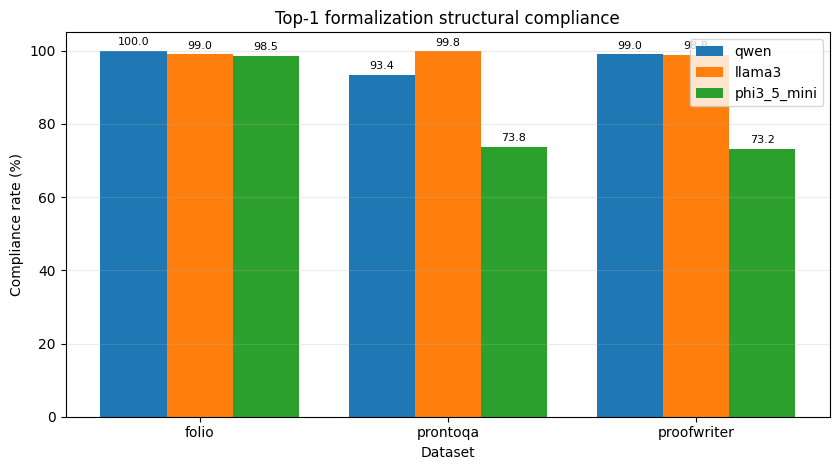

Figure PDF sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\f1_format_compliance.pdf
Figure PNG sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\f1_format_compliance.png


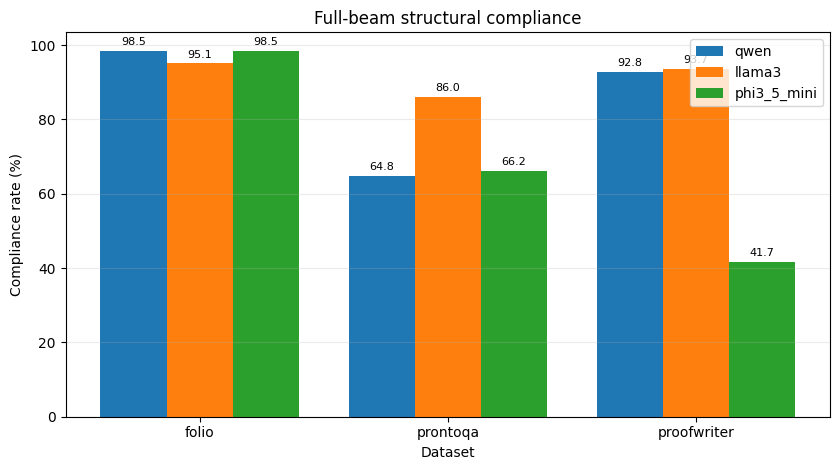

Figure PDF sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\beam_all_format_compliance.pdf
Figure PNG sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\beam_all_format_compliance.png


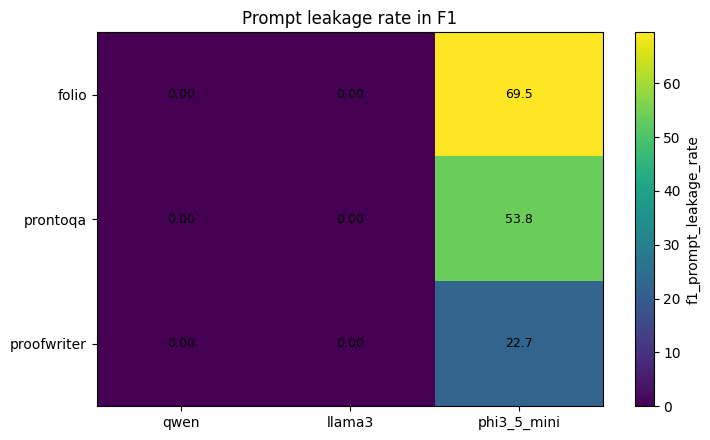

Figure PDF sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\f1_prompt_leakage_heatmap.pdf
Figure PNG sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\f1_prompt_leakage_heatmap.png


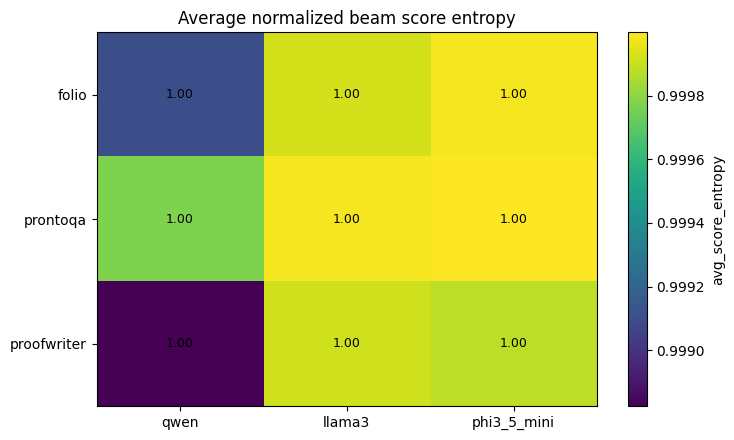

Figure PDF sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\beam_score_entropy_heatmap.pdf
Figure PNG sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\beam_score_entropy_heatmap.png


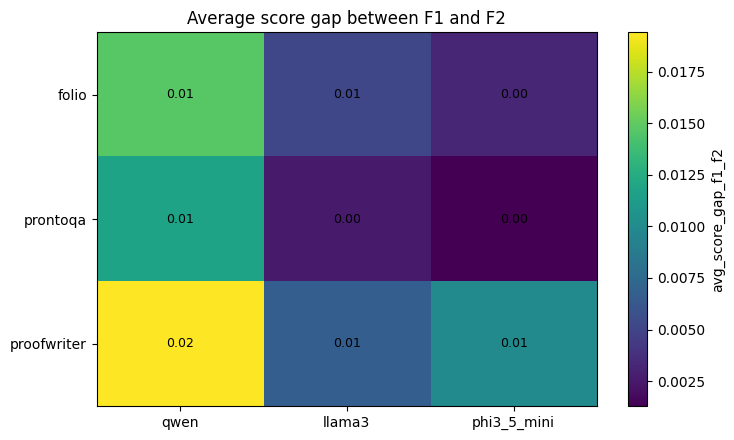

Figure PDF sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\score_gap_f1_f2_heatmap.pdf
Figure PNG sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\score_gap_f1_f2_heatmap.png


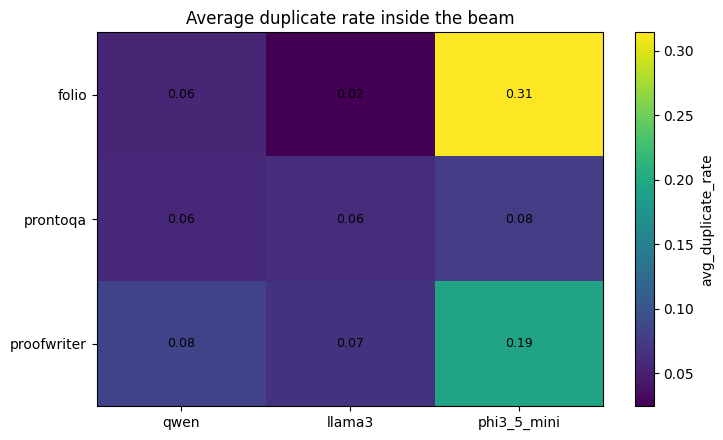

Figure PDF sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\duplicate_rate_heatmap.pdf
Figure PNG sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\duplicate_rate_heatmap.png


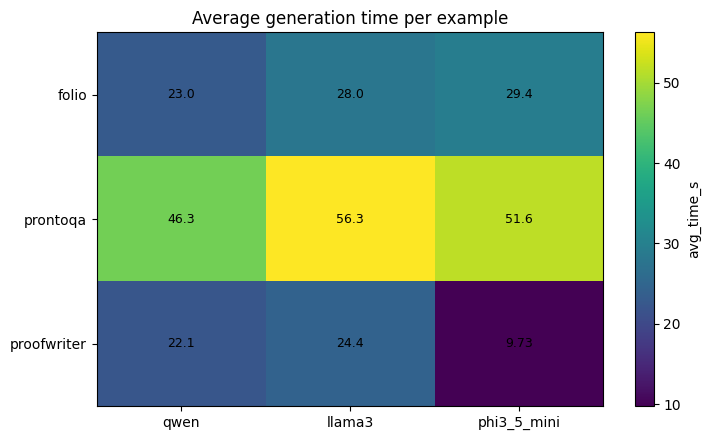

Figure PDF sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\average_generation_time_heatmap.pdf
Figure PNG sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\average_generation_time_heatmap.png


In [8]:
plot_grouped_bar(
    summary_df,
    value_col="f1_format_ok_rate",
    title="Top-1 formalization structural compliance",
    ylabel="Compliance rate (%)",
    filename="f1_format_compliance",
)

plot_grouped_bar(
    summary_df,
    value_col="beam_all_format_ok_rate",
    title="Full-beam structural compliance",
    ylabel="Compliance rate (%)",
    filename="beam_all_format_compliance",
)

plot_heatmap(
    summary_df,
    value_col="f1_prompt_leakage_rate",
    title="Prompt leakage rate in F1",
    filename="f1_prompt_leakage_heatmap",
)

plot_heatmap(
    summary_df,
    value_col="avg_score_entropy",
    title="Average normalized beam score entropy",
    filename="beam_score_entropy_heatmap",
)

plot_heatmap(
    summary_df,
    value_col="avg_score_gap_f1_f2",
    title="Average score gap between F1 and F2",
    filename="score_gap_f1_f2_heatmap",
)

plot_heatmap(
    summary_df,
    value_col="avg_duplicate_rate",
    title="Average duplicate rate inside the beam",
    filename="duplicate_rate_heatmap",
)

plot_heatmap(
    summary_df,
    value_col="avg_time_s",
    title="Average generation time per example",
    filename="average_generation_time_heatmap",
)

In [9]:
def best_and_worst(df: pd.DataFrame, metric: str):
    clean_df = df.dropna(subset=[metric])

    if clean_df.empty:
        return None, None

    best = clean_df.loc[clean_df[metric].idxmax()]
    worst = clean_df.loc[clean_df[metric].idxmin()]

    return best, worst


metrics_to_comment = [
    "f1_format_ok_rate",
    "beam_all_format_ok_rate",
    "f1_prompt_leakage_rate",
    "avg_score_entropy",
    "avg_score_gap_f1_f2",
    "avg_duplicate_rate",
    "avg_time_s",
]

for metric in metrics_to_comment:
    best, worst = best_and_worst(summary_df, metric)

    print("=" * 80)
    print("Metric:", metric)

    if best is not None:
        print(
            f"Max: {best['model']} / {best['dataset']} = {best[metric]:.3f}"
        )
        print(
            f"Min: {worst['model']} / {worst['dataset']} = {worst[metric]:.3f}"
        )

Metric: f1_format_ok_rate
Max: qwen / folio = 100.000
Min: phi3_5_mini / proofwriter = 73.167
Metric: beam_all_format_ok_rate
Max: qwen / folio = 98.522
Min: phi3_5_mini / proofwriter = 41.667
Metric: f1_prompt_leakage_rate
Max: phi3_5_mini / folio = 69.458
Min: qwen / folio = 0.000
Metric: avg_score_entropy
Max: phi3_5_mini / prontoqa = 1.000
Min: qwen / proofwriter = 0.999
Metric: avg_score_gap_f1_f2
Max: qwen / proofwriter = 0.019
Min: phi3_5_mini / prontoqa = 0.001
Metric: avg_duplicate_rate
Max: phi3_5_mini / folio = 0.314
Min: llama3 / folio = 0.025
Metric: avg_time_s
Max: llama3 / prontoqa = 56.274
Min: phi3_5_mini / proofwriter = 9.734


BASE_DIR   : C:\Users\mathlouthi\POSS-LOGIC-LM
TABLES_DIR : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\tables
FIGURES_DIR: C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures

Anciennes tables supprimées :
- formalization_quality_summary.csv
- formalization_quality_summary.xlsx

Anciennes figures supprimées :
- average_generation_time_heatmap.pdf
- average_generation_time_heatmap.png
- beam_all_format_compliance.pdf
- beam_all_format_compliance.png
- beam_score_entropy_heatmap.pdf
- beam_score_entropy_heatmap.png
- duplicate_rate_heatmap.pdf
- duplicate_rate_heatmap.png
- f1_format_compliance.pdf
- f1_format_compliance.png
- f1_prompt_leakage_heatmap.pdf
- f1_prompt_leakage_heatmap.png
- score_gap_f1_f2_heatmap.pdf
- score_gap_f1_f2_heatmap.png

Tableaux conservés :
- C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\tables\top1_structural_compliance.csv
- C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\tables\full_beam_structural_compliance.csv
- C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\tables\formal

model,qwen,llama3,phi3_5_mini
dataset,,,
folio,100.0,99.01,98.52
prontoqa,93.4,99.80,73.80
proofwriter,99.0,98.83,73.17



Table 2 — Full-beam structural compliance:


model,qwen,llama3,phi3_5_mini
dataset,,,
folio,98.52,95.07,98.52
prontoqa,64.80,86.00,66.20
proofwriter,92.83,93.67,41.67


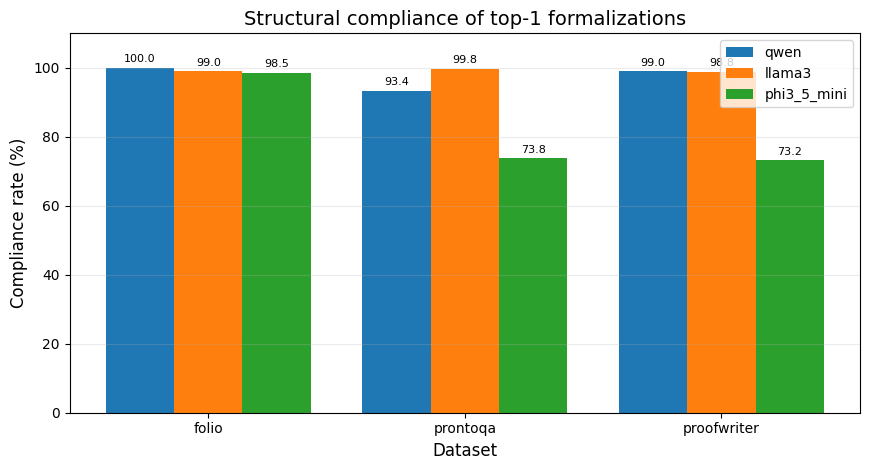

Figure PDF sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\top1_structural_compliance.pdf
Figure PNG sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\top1_structural_compliance.png


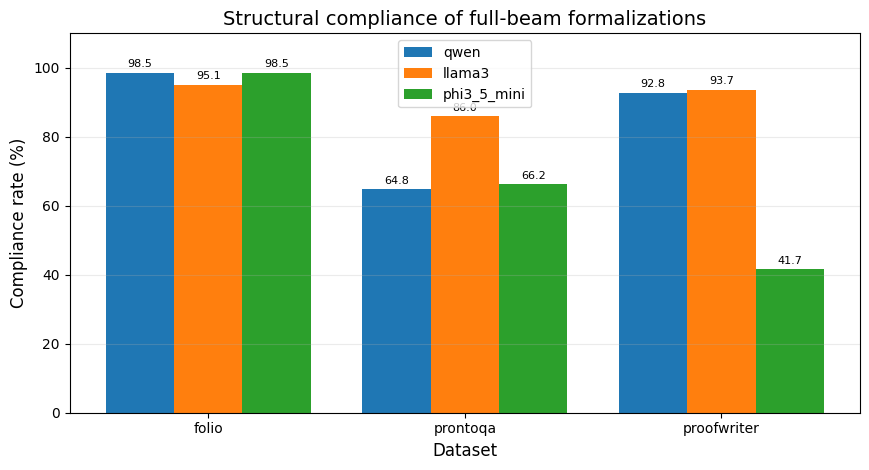

Figure PDF sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\full_beam_structural_compliance.pdf
Figure PNG sauvegardée : C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\full_beam_structural_compliance.png

Nettoyage terminé.
Seules les 2 figures principales ont été régénérées.
Seuls les 2 tableaux principaux ont été conservés.

Figures finales :
- full_beam_structural_compliance.pdf
- full_beam_structural_compliance.png
- top1_structural_compliance.pdf
- top1_structural_compliance.png

Tables finales :
- formalization_quality_key_tables.xlsx
- full_beam_structural_compliance.csv
- top1_structural_compliance.csv


In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Vérification des chemins
# ============================================================

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

OUTPUT_DIR = BASE_DIR / "outputs"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR   :", BASE_DIR)
print("TABLES_DIR :", TABLES_DIR)
print("FIGURES_DIR:", FIGURES_DIR)


# ============================================================
# 2. Supprimer les anciens outputs inutiles
# ============================================================

def clean_directory(directory: Path, extensions=(".csv", ".xlsx", ".pdf", ".png", ".jpg", ".jpeg")):
    deleted_files = []

    for file_path in directory.glob("*"):
        if file_path.is_file() and file_path.suffix.lower() in extensions:
            file_path.unlink()
            deleted_files.append(file_path.name)

    return deleted_files


deleted_tables = clean_directory(TABLES_DIR)
deleted_figures = clean_directory(FIGURES_DIR)

print("\nAnciennes tables supprimées :")
for name in deleted_tables:
    print("-", name)

print("\nAnciennes figures supprimées :")
for name in deleted_figures:
    print("-", name)


# ============================================================
# 3. Vérifier que summary_df existe
# ============================================================

if "summary_df" not in globals():
    raise RuntimeError(
        "summary_df n'existe pas encore. "
        "Exécute d'abord les cellules qui calculent les métriques."
    )

required_columns = {
    "model",
    "dataset",
    "f1_format_ok_rate",
    "beam_all_format_ok_rate",
}

missing_columns = required_columns - set(summary_df.columns)

if missing_columns:
    raise ValueError(f"Colonnes manquantes dans summary_df : {missing_columns}")


# ============================================================
# 4. Garder seulement les 2 tableaux les plus importants
# ============================================================

MODEL_ORDER = ["qwen", "llama3", "phi3_5_mini"]
DATASET_ORDER = ["folio", "prontoqa", "proofwriter"]


def make_ordered_pivot(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    pivot = df.pivot(index="dataset", columns="model", values=value_col)

    available_datasets = [d for d in DATASET_ORDER if d in pivot.index]
    available_models = [m for m in MODEL_ORDER if m in pivot.columns]

    pivot = pivot.loc[available_datasets, available_models]

    return pivot.round(2)


top1_compliance_table = make_ordered_pivot(
    summary_df,
    "f1_format_ok_rate"
)

full_beam_compliance_table = make_ordered_pivot(
    summary_df,
    "beam_all_format_ok_rate"
)


# Sauvegarde en CSV
top1_csv_path = TABLES_DIR / "top1_structural_compliance.csv"
full_beam_csv_path = TABLES_DIR / "full_beam_structural_compliance.csv"

top1_compliance_table.to_csv(top1_csv_path, encoding="utf-8")
full_beam_compliance_table.to_csv(full_beam_csv_path, encoding="utf-8")


# Sauvegarde dans un seul fichier Excel avec 2 feuilles
excel_path = TABLES_DIR / "formalization_quality_key_tables.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    top1_compliance_table.to_excel(writer, sheet_name="Top1 compliance")
    full_beam_compliance_table.to_excel(writer, sheet_name="Full beam compliance")


print("\nTableaux conservés :")
print("-", top1_csv_path)
print("-", full_beam_csv_path)
print("-", excel_path)

print("\nTable 1 — Top-1 structural compliance:")
display(top1_compliance_table)

print("\nTable 2 — Full-beam structural compliance:")
display(full_beam_compliance_table)


# ============================================================
# 5. Fonction propre pour générer uniquement les 2 figures finales
# ============================================================

def save_figure(filename: str):
    pdf_path = FIGURES_DIR / f"{filename}.pdf"
    png_path = FIGURES_DIR / f"{filename}.png"

    plt.tight_layout()
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Figure PDF sauvegardée :", pdf_path)
    print("Figure PNG sauvegardée :", png_path)


def plot_grouped_bar(
    df: pd.DataFrame,
    value_col: str,
    title: str,
    ylabel: str,
    filename: str,
):
    datasets = [d for d in DATASET_ORDER if d in set(df["dataset"])]
    models = [m for m in MODEL_ORDER if m in set(df["model"])]

    x = np.arange(len(datasets))
    width = 0.8 / max(len(models), 1)

    plt.figure(figsize=(8.8, 4.8))

    for idx, model in enumerate(models):
        values = []

        for dataset in datasets:
            row = df[
                (df["model"] == model)
                & (df["dataset"] == dataset)
            ]

            if row.empty:
                values.append(np.nan)
            else:
                values.append(float(row.iloc[0][value_col]))

        offset = (idx - (len(models) - 1) / 2) * width

        plt.bar(
            x + offset,
            values,
            width,
            label=model
        )

        for xpos, value in zip(x + offset, values):
            if not pd.isna(value):
                plt.text(
                    xpos,
                    value + 1,
                    f"{value:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    plt.title(title, fontsize=14)
    plt.xlabel("Dataset", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(x, datasets)
    plt.ylim(0, 110)
    plt.legend()
    plt.grid(axis="y", alpha=0.25)

    save_figure(filename)


# ============================================================
# 6. Générer uniquement les 2 figures à garder
# ============================================================

plot_grouped_bar(
    summary_df,
    value_col="f1_format_ok_rate",
    title="Structural compliance of top-1 formalizations",
    ylabel="Compliance rate (%)",
    filename="top1_structural_compliance",
)

plot_grouped_bar(
    summary_df,
    value_col="beam_all_format_ok_rate",
    title="Structural compliance of full-beam formalizations",
    ylabel="Compliance rate (%)",
    filename="full_beam_structural_compliance",
)


# ============================================================
# 7. Résumé final
# ============================================================

print("\nNettoyage terminé.")
print("Seules les 2 figures principales ont été régénérées.")
print("Seuls les 2 tableaux principaux ont été conservés.")

print("\nFigures finales :")
for file_path in sorted(FIGURES_DIR.glob("*")):
    print("-", file_path.name)

print("\nTables finales :")
for file_path in sorted(TABLES_DIR.glob("*")):
    print("-", file_path.name)

BASE_DIR: C:\Users\mathlouthi\POSS-LOGIC-LM
FIGURES_DIR: C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures
Deleted: top1_structural_compliance.pdf
Deleted: top1_structural_compliance.png
Deleted: full_beam_structural_compliance.pdf
Deleted: full_beam_structural_compliance.png


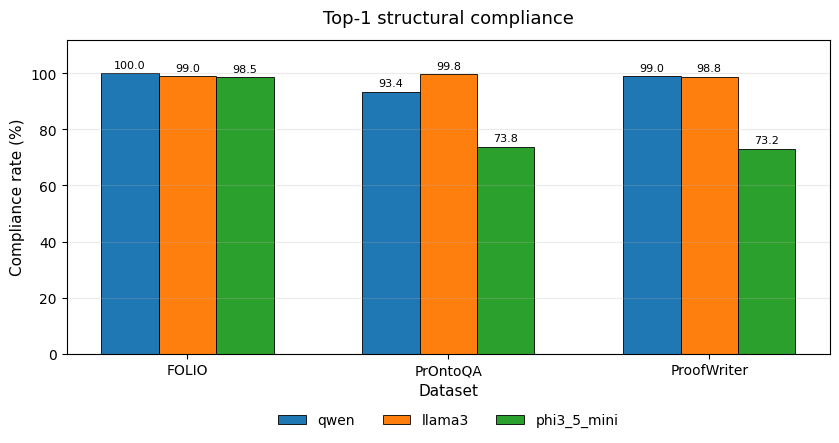

Saved PDF: C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\top1_structural_compliance.pdf
Saved PNG: C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\top1_structural_compliance.png


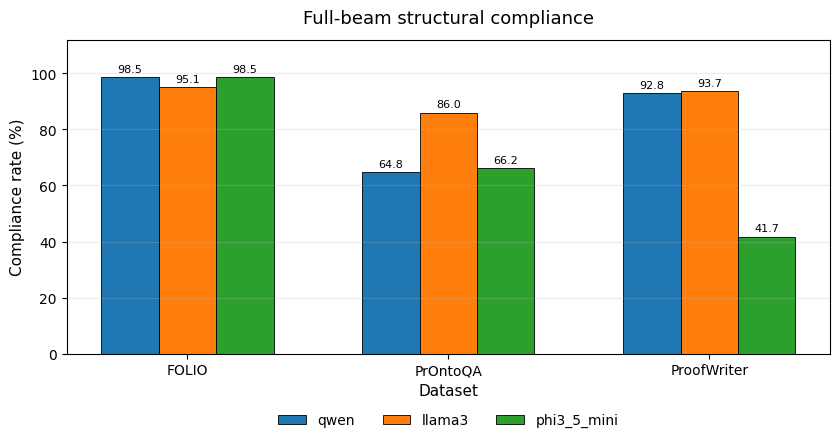

Saved PDF: C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\full_beam_structural_compliance.pdf
Saved PNG: C:\Users\mathlouthi\POSS-LOGIC-LM\outputs\figures\full_beam_structural_compliance.png

Final tables:


,Qwen,Llama3,Phi3.5-mini
FOLIO,100.0,99.01,98.52
PrOntoQA,93.4,99.80,73.80
ProofWriter,99.0,98.83,73.17


,Qwen,Llama3,Phi3.5-mini
FOLIO,98.52,95.07,98.52
PrOntoQA,64.80,86.00,66.20
ProofWriter,92.83,93.67,41.67



Final figures:
- full_beam_structural_compliance.pdf
- full_beam_structural_compliance.png
- top1_structural_compliance.pdf
- top1_structural_compliance.png


In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Chemins
# ============================================================

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

OUTPUT_DIR = BASE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ["qwen", "llama3", "phi3_5_mini"]
DATASET_ORDER = ["folio", "prontoqa", "proofwriter"]

print("BASE_DIR:", BASE_DIR)
print("FIGURES_DIR:", FIGURES_DIR)


# ============================================================
# 2. Supprimer uniquement les anciennes figures finales
# ============================================================

files_to_delete = [
    "top1_structural_compliance.pdf",
    "top1_structural_compliance.png",
    "full_beam_structural_compliance.pdf",
    "full_beam_structural_compliance.png",
]

for filename in files_to_delete:
    file_path = FIGURES_DIR / filename
    if file_path.exists():
        file_path.unlink()
        print("Deleted:", file_path.name)


# ============================================================
# 3. Vérification de summary_df
# ============================================================

if "summary_df" not in globals():
    raise RuntimeError(
        "summary_df n'existe pas. Exécute d'abord les cellules de calcul des métriques."
    )

required_columns = {
    "model",
    "dataset",
    "f1_format_ok_rate",
    "beam_all_format_ok_rate",
}

missing_columns = required_columns - set(summary_df.columns)

if missing_columns:
    raise ValueError(f"Colonnes manquantes dans summary_df : {missing_columns}")


# ============================================================
# 4. Fonction de sauvegarde
# ============================================================

def save_figure(filename: str):
    pdf_path = FIGURES_DIR / f"{filename}.pdf"
    png_path = FIGURES_DIR / f"{filename}.png"

    plt.tight_layout()
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved PDF:", pdf_path)
    print("Saved PNG:", png_path)


# ============================================================
# 5. Figure propre en barres groupées
# ============================================================

def plot_structural_compliance(
    df: pd.DataFrame,
    value_col: str,
    title: str,
    filename: str,
):
    datasets = [d for d in DATASET_ORDER if d in set(df["dataset"])]
    models = [m for m in MODEL_ORDER if m in set(df["model"])]

    x = np.arange(len(datasets))
    width = 0.22

    fig, ax = plt.subplots(figsize=(8.5, 4.6))

    for idx, model in enumerate(models):
        values = []

        for dataset in datasets:
            row = df[
                (df["model"] == model)
                & (df["dataset"] == dataset)
            ]

            if row.empty:
                values.append(np.nan)
            else:
                values.append(float(row.iloc[0][value_col]))

        offset = (idx - (len(models) - 1) / 2) * width

        bars = ax.bar(
            x + offset,
            values,
            width,
            label=model,
            edgecolor="black",
            linewidth=0.6,
        )

        for bar, value in zip(bars, values):
            if not pd.isna(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value + 1.2,
                    f"{value:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel("Dataset", fontsize=11)
    ax.set_ylabel("Compliance rate (%)", fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(["FOLIO", "PrOntoQA", "ProofWriter"])

    ax.set_ylim(0, 112)
    ax.grid(axis="y", alpha=0.25)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=3,
        frameon=False,
    )

    save_figure(filename)


# ============================================================
# 6. Générer uniquement les deux figures finales
# ============================================================

plot_structural_compliance(
    summary_df,
    value_col="f1_format_ok_rate",
    title="Top-1 structural compliance",
    filename="top1_structural_compliance",
)

plot_structural_compliance(
    summary_df,
    value_col="beam_all_format_ok_rate",
    title="Full-beam structural compliance",
    filename="full_beam_structural_compliance",
)


# ============================================================
# 7. Sauvegarder uniquement les deux tableaux associés
# ============================================================

def make_pivot_table(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    pivot = df.pivot(index="dataset", columns="model", values=value_col)

    available_datasets = [d for d in DATASET_ORDER if d in pivot.index]
    available_models = [m for m in MODEL_ORDER if m in pivot.columns]

    pivot = pivot.loc[available_datasets, available_models]
    pivot.index = ["FOLIO", "PrOntoQA", "ProofWriter"]
    pivot.columns = ["Qwen", "Llama3", "Phi3.5-mini"]

    return pivot.round(2)


top1_table = make_pivot_table(summary_df, "f1_format_ok_rate")
full_beam_table = make_pivot_table(summary_df, "beam_all_format_ok_rate")

top1_table.to_csv(TABLES_DIR / "top1_structural_compliance.csv", encoding="utf-8")
full_beam_table.to_csv(TABLES_DIR / "full_beam_structural_compliance.csv", encoding="utf-8")

with pd.ExcelWriter(TABLES_DIR / "formalization_quality_key_tables.xlsx", engine="openpyxl") as writer:
    top1_table.to_excel(writer, sheet_name="Top-1 compliance")
    full_beam_table.to_excel(writer, sheet_name="Full-beam compliance")

print("\nFinal tables:")
display(top1_table)
display(full_beam_table)

print("\nFinal figures:")
for file_path in sorted(FIGURES_DIR.glob("*structural_compliance*")):
    print("-", file_path.name)